### RFM 분석 실습
- Recency: 얼마나 최근에 구매했는가
- Frequency: 얼마나 자주 구매했는가
- Monetary: 얼마나 많은 금액을 지출했는가

### 고객 분석
`customer_invoice_data.csv`
- InvoiceNo: 거래 번호
- StockCode: 상품 코드
- Description: 상품명 
- InvoiceDate: 거래 날짜
- UnitPrice: 상품 단가
- CustomerID: 고객 번호
- Country: 국가명

In [193]:
import pandas as pd

ci_df = pd.read_csv('./datasets/customer_invoice_data.csv')
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [194]:
ci_df.isna().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [195]:
ci_df = ci_df.drop(index=ci_df[ci_df.CustomerID.isna()].index, axis=0)
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [196]:
ci_df = ci_df[ci_df.UnitPrice > 0] 
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [197]:
ci_df.UnitPrice.min()

np.float64(0.001)

In [198]:
rfm_f = ci_df.CustomerID.value_counts().to_frame().reset_index()
rfm_f

,CustomerID,count
0,17841.0,7983
1,14911.0,5901
2,14096.0,5128
3,12748.0,4641
4,14606.0,2782
...,...,...
4366,14424.0,1
4367,18184.0,1
4368,13017.0,1
4369,18174.0,1


In [199]:
rfm_f = rfm_f.rename(columns={'count': 'Frequency'})
rfm_f

,CustomerID,Frequency
0,17841.0,7983
1,14911.0,5901
2,14096.0,5128
3,12748.0,4641
4,14606.0,2782
...,...,...
4366,14424.0,1
4367,18184.0,1
4368,13017.0,1
4369,18174.0,1


In [200]:
ci_df['Monetary'] = ci_df.Quantity * ci_df.UnitPrice
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [201]:
ci_df.Monetary.describe()

count    406789.000000
mean         20.403860
std         427.612692
min     -168469.600000
25%           4.200000
50%          11.100000
75%          19.500000
max      168469.600000
Name: Monetary, dtype: float64

In [202]:
ci_df = ci_df[ci_df.Monetary > 0]
ci_df.Monetary.min()

np.float64(0.001)

In [203]:
ci_df.InvoiceDate = pd.to_datetime(ci_df.InvoiceDate)
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60


In [204]:
ci_df.sort_values(by='InvoiceDate', ascending=False)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France,14.85
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,2011-12-09 12:50:00,1.95,12680.0,France,15.60
541895,581587,22556,PLASTERS IN TIN CIRCUS PARADE,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541896,581587,22555,PLASTERS IN TIN STRONGMAN,12,2011-12-09 12:50:00,1.65,12680.0,France,19.80
541897,581587,22728,ALARM CLOCK BAKELIKE PINK,4,2011-12-09 12:50:00,3.75,12680.0,France,15.00
...,...,...,...,...,...,...,...,...,...
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom,15.30
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom,25.50


In [205]:
target_date = pd.to_datetime('2011-12-10')
ci_df['Recency'] = (target_date - ci_df.InvoiceDate).dt.days
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0


In [206]:
ci_df = ci_df.drop(['InvoiceDate'], axis=1)
ci_df

,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID,Country,Monetary,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,3.39,17850.0,United Kingdom,20.34,373
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,0.85,12680.0,France,10.20,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2.10,12680.0,France,12.60,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,4.15,12680.0,France,16.60,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,4.15,12680.0,France,16.60,0


In [207]:
rfm_r = ci_df.groupby('CustomerID')['Recency'].min().to_frame().reset_index()
rfm_r

,CustomerID,Recency
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310
...,...,...
4333,18280.0,277
4334,18281.0,180
4335,18282.0,7
4336,18283.0,3


In [208]:
rfm_m = ci_df.groupby('CustomerID')['Monetary'].sum().to_frame().reset_index()
rfm_m

,CustomerID,Monetary
0,12346.0,77183.60
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4333,18280.0,180.60
4334,18281.0,80.82
4335,18282.0,178.05
4336,18283.0,2094.88


In [209]:
rfm_rf = rfm_r.merge(rfm_f, on='CustomerID')
rfm = rfm_rf.merge(rfm_m, on='CustomerID')
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,325,2,77183.60
1,12347.0,2,182,4310.00
2,12348.0,75,31,1797.24
3,12349.0,18,73,1757.55
4,12350.0,310,17,334.40
...,...,...,...,...
4333,18280.0,277,10,180.60
4334,18281.0,180,7,80.82
4335,18282.0,7,13,178.05
4336,18283.0,3,756,2094.88


In [210]:
from sklearn.preprocessing import MinMaxScaler

rfm_scale = MinMaxScaler()
rfm_scale = rfm_scale.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

In [211]:
rfm[['Recency', 'Frequency', 'Monetary']] = pd.DataFrame(rfm_scale, columns=['Recency', 'Frequency', 'Monetary'])

In [212]:
rfm['Recency'] = 1 - rfm.Recency
rfm

,CustomerID,Recency,Frequency,Monetary
0,12346.0,0.128686,0.000125,0.275443
1,12347.0,0.994638,0.022676,0.015368
2,12348.0,0.798928,0.003758,0.006401
3,12349.0,0.951743,0.009020,0.006259
4,12350.0,0.168901,0.002005,0.001180
...,...,...,...,...
4333,18280.0,0.257373,0.001128,0.000631
4334,18281.0,0.517426,0.000752,0.000275
4335,18282.0,0.981233,0.001503,0.000622
4336,18283.0,0.991957,0.094588,0.007463


In [213]:
rfm['TotalScore'] = rfm.Recency + rfm.Frequency + rfm.Monetary
rfm

,CustomerID,Recency,Frequency,Monetary,TotalScore
0,12346.0,0.128686,0.000125,0.275443,0.404255
1,12347.0,0.994638,0.022676,0.015368,1.032682
2,12348.0,0.798928,0.003758,0.006401,0.809087
3,12349.0,0.951743,0.009020,0.006259,0.967022
4,12350.0,0.168901,0.002005,0.001180,0.172085
...,...,...,...,...,...
4333,18280.0,0.257373,0.001128,0.000631,0.259131
4334,18281.0,0.517426,0.000752,0.000275,0.518453
4335,18282.0,0.981233,0.001503,0.000622,0.983359
4336,18283.0,0.991957,0.094588,0.007463,1.094008


In [214]:
import numpy as np

l1, l2, l3, l4 = np.percentile(rfm['TotalScore'], [20, 40, 70, 90])
print(l1, l2, l3, l4)

0.5279694904167397 0.8186966877592639 0.9577880412775496 1.012020182849361


In [215]:
def get_level(x):
    if x <= l1:
        return 5
    if x <= l2:
        return 4
    if x <= l3:
        return 3
    if x <= l4:
        return 2
    return 1

In [216]:
rfm['Grade'] = rfm.TotalScore.apply(get_level)
rfm

,CustomerID,Recency,Frequency,Monetary,TotalScore,Grade
0,12346.0,0.128686,0.000125,0.275443,0.404255,5
1,12347.0,0.994638,0.022676,0.015368,1.032682,1
2,12348.0,0.798928,0.003758,0.006401,0.809087,4
3,12349.0,0.951743,0.009020,0.006259,0.967022,2
4,12350.0,0.168901,0.002005,0.001180,0.172085,5
...,...,...,...,...,...,...
4333,18280.0,0.257373,0.001128,0.000631,0.259131,5
4334,18281.0,0.517426,0.000752,0.000275,0.518453,5
4335,18282.0,0.981233,0.001503,0.000622,0.983359,2
4336,18283.0,0.991957,0.094588,0.007463,1.094008,1


In [217]:
rfm['Grade'] = rfm['Grade'].replace([5, 4, 3, 2, 1], 
                                                ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP'])

In [218]:
rfm

,CustomerID,Recency,Frequency,Monetary,TotalScore,Grade
0,12346.0,0.128686,0.000125,0.275443,0.404255,Bronze
1,12347.0,0.994638,0.022676,0.015368,1.032682,VIP
2,12348.0,0.798928,0.003758,0.006401,0.809087,Silver
3,12349.0,0.951743,0.009020,0.006259,0.967022,Diamond
4,12350.0,0.168901,0.002005,0.001180,0.172085,Bronze
...,...,...,...,...,...,...
4333,18280.0,0.257373,0.001128,0.000631,0.259131,Bronze
4334,18281.0,0.517426,0.000752,0.000275,0.518453,Bronze
4335,18282.0,0.981233,0.001503,0.000622,0.983359,Diamond
4336,18283.0,0.991957,0.094588,0.007463,1.094008,VIP


In [219]:
ci_df[['CustomerID', 'Country']].merge(rfm, on='CustomerID')

,CustomerID,Country,Recency,Frequency,Monetary,TotalScore,Grade
0,17850.0,United Kingdom,0.002681,0.038963,0.019227,0.060871,Bronze
1,17850.0,United Kingdom,0.002681,0.038963,0.019227,0.060871,Bronze
2,17850.0,United Kingdom,0.002681,0.038963,0.019227,0.060871,Bronze
3,17850.0,United Kingdom,0.002681,0.038963,0.019227,0.060871,Bronze
4,17850.0,United Kingdom,0.002681,0.038963,0.019227,0.060871,Bronze
...,...,...,...,...,...,...,...
397879,12680.0,France,1.000000,0.006389,0.003066,1.009455,Diamond
397880,12680.0,France,1.000000,0.006389,0.003066,1.009455,Diamond
397881,12680.0,France,1.000000,0.006389,0.003066,1.009455,Diamond
397882,12680.0,France,1.000000,0.006389,0.003066,1.009455,Diamond


### 심화 버전
- 취소 건수도 포함시켜 분석

In [220]:
import pandas as pd

ci_df = pd.read_csv('./datasets/customer_invoice_data.csv')
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [221]:
ci_df = ci_df.drop(ci_df[ci_df.CustomerID.isna()].index, axis=0)
ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France


In [222]:
import numpy as np

# ci_df.InvoiceNo.astype(np.int64)
# ci_df[ci_df.InvoiceNo.str.contains('C')]
# ci_df[ci_df.InvoiceNo.str.contains('536391')]
ci_df[ci_df.CustomerID == 17548]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,12/1/2010 10:24,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,12/1/2010 10:24,1.65,17548.0,United Kingdom
165024,550755,22585,PACK OF 6 BIRDY GIFT TAGS,24,4/20/2011 12:01,1.25,17548.0,United Kingdom
165025,550755,22082,RIBBON REEL STRIPES DESIGN,10,4/20/2011 12:01,1.65,17548.0,United Kingdom
165026,550755,22081,RIBBON REEL FLORA + FAUNA,10,4/20/2011 12:01,1.65,17548.0,United Kingdom


In [223]:
ci_df['Monetary'] = ci_df.Quantity * ci_df.UnitPrice

In [224]:
ci_monetary_df = ci_df.groupby('CustomerID')[['Monetary']].sum()

In [225]:
ci_monetary_df.reset_index(inplace=True)
ci_monetary_df

,CustomerID,Monetary
0,12346.0,0.00
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
...,...,...
4367,18280.0,180.60
4368,18281.0,80.82
4369,18282.0,176.60
4370,18283.0,2094.88


In [226]:
ci_monetary_df = ci_monetary_df[ci_monetary_df.Monetary > 0]
ci_monetary_df

,CustomerID,Monetary
1,12347.0,4310.00
2,12348.0,1797.24
3,12349.0,1757.55
4,12350.0,334.40
5,12352.0,1545.41
...,...,...
4367,18280.0,180.60
4368,18281.0,80.82
4369,18282.0,176.60
4370,18283.0,2094.88


In [227]:
real_ci_df = ci_df[~ci_df.InvoiceNo.str.contains('C')]
real_ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,20.34
...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France,10.20
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France,12.60
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France,16.60
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France,16.60


In [228]:
ci_frequency_df = real_ci_df.CustomerID.value_counts().to_frame().reset_index()
ci_frequency_df

,CustomerID,count
0,17841.0,7847
1,14911.0,5677
2,14096.0,5111
3,12748.0,4596
4,14606.0,2700
...,...,...
4334,18184.0,1
4335,13256.0,1
4336,13017.0,1
4337,18174.0,1


In [229]:
real_ci_df.InvoiceDate = pd.to_datetime(real_ci_df.InvoiceDate)
real_ci_df['InvoiceDate'].sort_values(ascending=False)

541908   2011-12-09 12:50:00
541901   2011-12-09 12:50:00
541895   2011-12-09 12:50:00
541896   2011-12-09 12:50:00
541897   2011-12-09 12:50:00
                 ...        
3        2010-12-01 08:26:00
1        2010-12-01 08:26:00
5        2010-12-01 08:26:00
6        2010-12-01 08:26:00
0        2010-12-01 08:26:00
Name: InvoiceDate, Length: 397924, dtype: datetime64[us]

In [230]:
target_date = pd.to_datetime('2011-12-10')
real_ci_df['Recency'] = (target_date - real_ci_df['InvoiceDate']).dt.days
real_ci_df

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Monetary,Recency
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,373
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,373
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,373
...,...,...,...,...,...,...,...,...,...,...
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France,10.20,0
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France,12.60,0
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France,16.60,0


In [231]:
ci_recency_df = real_ci_df.groupby('CustomerID')['Recency'].min().reset_index()
ci_recency_df

,CustomerID,Recency
0,12346.0,325
1,12347.0,2
2,12348.0,75
3,12349.0,18
4,12350.0,310
...,...,...
4334,18280.0,277
4335,18281.0,180
4336,18282.0,7
4337,18283.0,3


In [232]:
ci_rf_df = ci_recency_df.merge(ci_frequency_df, on='CustomerID')
ci_rfm_df = ci_rf_df.merge(ci_monetary_df, on='CustomerID')
ci_rfm_df

,CustomerID,Recency,count,Monetary
0,12347.0,2,182,4310.00
1,12348.0,75,31,1797.24
2,12349.0,18,73,1757.55
3,12350.0,310,17,334.40
4,12352.0,36,85,1545.41
...,...,...,...,...
4317,18280.0,277,10,180.60
4318,18281.0,180,7,80.82
4319,18282.0,7,12,176.60
4320,18283.0,3,756,2094.88


In [233]:
ci_rfm_df = ci_rfm_df.rename(columns={'count': 'Frequency'})
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary
0,12347.0,2,182,4310.00
1,12348.0,75,31,1797.24
2,12349.0,18,73,1757.55
3,12350.0,310,17,334.40
4,12352.0,36,85,1545.41
...,...,...,...,...
4317,18280.0,277,10,180.60
4318,18281.0,180,7,80.82
4319,18282.0,7,12,176.60
4320,18283.0,3,756,2094.88


In [234]:
from sklearn.preprocessing import MinMaxScaler

rfm_scale = MinMaxScaler()
rfm_scale = rfm_scale.fit_transform(ci_rfm_df[['Recency', 'Frequency', 'Monetary']])

In [235]:
ci_rfm_df[['Recency', 'Frequency', 'Monetary']] = pd.DataFrame(rfm_scale, columns=['Recency', 'Frequency', 'Monetary'])

In [236]:
ci_rfm_df['Recency'] = 1 - ci_rfm_df.Recency
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary
0,12347.0,0.994638,0.023069,0.015421
1,12348.0,0.798928,0.003824,0.006430
2,12349.0,0.951743,0.009177,0.006288
3,12350.0,0.168901,0.002039,0.001196
4,12352.0,0.903485,0.010706,0.005529
...,...,...,...,...
4317,18280.0,0.257373,0.001147,0.000646
4318,18281.0,0.517426,0.000765,0.000289
4319,18282.0,0.981233,0.001402,0.000632
4320,18283.0,0.991957,0.096227,0.007495


In [237]:
ci_rfm_df['TotalScore'] = rfm[['Recency', 'Frequency', 'Monetary']].sum(axis=1)
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary,TotalScore
0,12347.0,0.994638,0.023069,0.015421,0.404255
1,12348.0,0.798928,0.003824,0.006430,1.032682
2,12349.0,0.951743,0.009177,0.006288,0.809087
3,12350.0,0.168901,0.002039,0.001196,0.967022
4,12352.0,0.903485,0.010706,0.005529,0.172085
...,...,...,...,...,...
4317,18280.0,0.257373,0.001147,0.000646,0.919056
4318,18281.0,0.517426,0.000765,0.000289,0.949126
4319,18282.0,0.981233,0.001402,0.000632,0.565708
4320,18283.0,0.991957,0.096227,0.007495,0.888368


In [238]:
import numpy as np

l1, l2, l3, l4 = np.percentile(ci_rfm_df['TotalScore'], [20, 40, 70, 90])
print(l1, l2, l3, l4)

0.527816123798206 0.8186795068489613 0.9579347583483308 1.0120136832829612


In [239]:
def get_level(x):
    if x <= l1:
        return 5
    if x <= l2:
        return 4
    if x <= l3:
        return 3
    if x <= l4:
        return 2
    return 1

In [240]:
ci_rfm_df['Grade'] = ci_rfm_df['TotalScore'].apply(get_level)
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary,TotalScore,Grade
0,12347.0,0.994638,0.023069,0.015421,0.404255,5
1,12348.0,0.798928,0.003824,0.006430,1.032682,1
2,12349.0,0.951743,0.009177,0.006288,0.809087,4
3,12350.0,0.168901,0.002039,0.001196,0.967022,2
4,12352.0,0.903485,0.010706,0.005529,0.172085,5
...,...,...,...,...,...,...
4317,18280.0,0.257373,0.001147,0.000646,0.919056,3
4318,18281.0,0.517426,0.000765,0.000289,0.949126,3
4319,18282.0,0.981233,0.001402,0.000632,0.565708,4
4320,18283.0,0.991957,0.096227,0.007495,0.888368,3


In [241]:
ci_rfm_df['Grade'] = ci_rfm_df['Grade'].replace([5, 4, 3, 2, 1], 
                                                ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP'])

In [242]:
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary,TotalScore,Grade
0,12347.0,0.994638,0.023069,0.015421,0.404255,Bronze
1,12348.0,0.798928,0.003824,0.006430,1.032682,VIP
2,12349.0,0.951743,0.009177,0.006288,0.809087,Silver
3,12350.0,0.168901,0.002039,0.001196,0.967022,Diamond
4,12352.0,0.903485,0.010706,0.005529,0.172085,Bronze
...,...,...,...,...,...,...
4317,18280.0,0.257373,0.001147,0.000646,0.919056,Gold
4318,18281.0,0.517426,0.000765,0.000289,0.949126,Gold
4319,18282.0,0.981233,0.001402,0.000632,0.565708,Silver
4320,18283.0,0.991957,0.096227,0.007495,0.888368,Gold


In [243]:
ci_result_df = real_ci_df[['CustomerID', 'Country']]
ci_result_df

,CustomerID,Country
0,17850.0,United Kingdom
1,17850.0,United Kingdom
2,17850.0,United Kingdom
3,17850.0,United Kingdom
4,17850.0,United Kingdom
...,...,...
541904,12680.0,France
541905,12680.0,France
541906,12680.0,France
541907,12680.0,France


In [244]:
ci_rfm_df

,CustomerID,Recency,Frequency,Monetary,TotalScore,Grade
0,12347.0,0.994638,0.023069,0.015421,0.404255,Bronze
1,12348.0,0.798928,0.003824,0.006430,1.032682,VIP
2,12349.0,0.951743,0.009177,0.006288,0.809087,Silver
3,12350.0,0.168901,0.002039,0.001196,0.967022,Diamond
4,12352.0,0.903485,0.010706,0.005529,0.172085,Bronze
...,...,...,...,...,...,...
4317,18280.0,0.257373,0.001147,0.000646,0.919056,Gold
4318,18281.0,0.517426,0.000765,0.000289,0.949126,Gold
4319,18282.0,0.981233,0.001402,0.000632,0.565708,Silver
4320,18283.0,0.991957,0.096227,0.007495,0.888368,Gold


In [245]:
ci_result_df = ci_result_df.merge(ci_rfm_df, on='CustomerID')
ci_result_df

,CustomerID,Country,Recency,Frequency,Monetary,TotalScore,Grade
0,17850.0,United Kingdom,0.002681,0.037726,0.018922,1.001485,Diamond
1,17850.0,United Kingdom,0.002681,0.037726,0.018922,1.001485,Diamond
2,17850.0,United Kingdom,0.002681,0.037726,0.018922,1.001485,Diamond
3,17850.0,United Kingdom,0.002681,0.037726,0.018922,1.001485,Diamond
4,17850.0,United Kingdom,0.002681,0.037726,0.018922,1.001485,Diamond
...,...,...,...,...,...,...,...
397810,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397811,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397812,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397813,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold


C:\Users\Administrator\AppData\Local\Temp\ipykernel_7904\3155261133.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = 'Grade', data=ci_result_df, palette='muted', order=order)


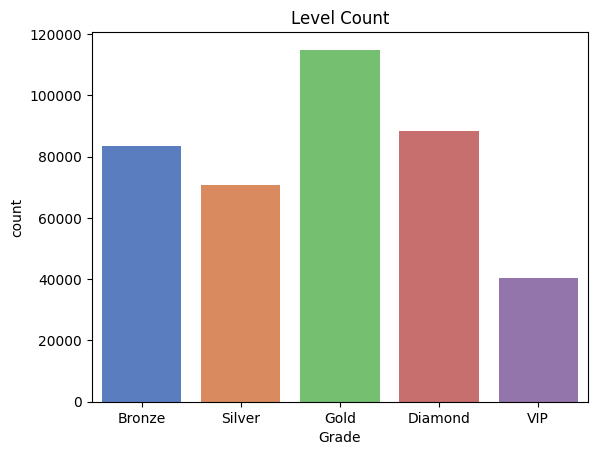

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP']

sns.countplot(x = 'Grade', data=ci_result_df, palette='muted', order=order)
plt.title('Level Count')
plt.show()

In [248]:
ci_country_df = ci_result_df.Country.value_counts().to_frame().reset_index()
ci_country_df

,Country,count
0,United Kingdom,354236
1,Germany,9042
2,France,8342
3,EIRE,7238
4,Spain,2485
5,Netherlands,2363
6,Belgium,2031
7,Switzerland,1842
8,Portugal,1462
9,Australia,1185


In [249]:
ci_country_df = ci_country_df.iloc[1:, :]
ci_country_df

,Country,count
1,Germany,9042
2,France,8342
3,EIRE,7238
4,Spain,2485
5,Netherlands,2363
6,Belgium,2031
7,Switzerland,1842
8,Portugal,1462
9,Australia,1185
10,Norway,1072


In [257]:
ci_result_df_1000 = ci_result_df[ci_result_df.Country.isin(ci_country_df[ci_country_df['count'] > 1000].Country)]
ci_result_df_1000

,CustomerID,Country,Recency,Frequency,Monetary,TotalScore,Grade
26,12583.0,France,0.994638,0.031354,0.025716,0.366373,Bronze
27,12583.0,France,0.994638,0.031354,0.025716,0.366373,Bronze
28,12583.0,France,0.994638,0.031354,0.025716,0.366373,Bronze
29,12583.0,France,0.994638,0.031354,0.025716,0.366373,Bronze
30,12583.0,France,0.994638,0.031354,0.025716,0.366373,Bronze
...,...,...,...,...,...,...,...
397810,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397811,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397812,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold
397813,12680.0,France,1.000000,0.006500,0.003087,0.855353,Gold


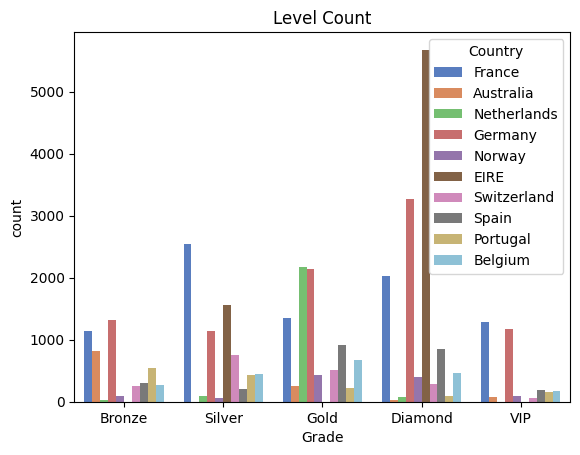

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP']

sns.countplot(x = 'Grade', data=ci_result_df_1000, palette='muted', order=order, hue='Country')
plt.title('Level Count')
plt.show()

In [261]:
condition1 = ci_country_df['count'] > 100
condition2 = ci_country_df['count'] < 1000
condition = condition1 & condition2

ci_result_df_100 = ci_result_df[ci_result_df.Country.isin(ci_country_df[condition].Country)]
ci_result_df_100

,CustomerID,Country,Recency,Frequency,Monetary,TotalScore,Grade
4430,12779.0,Poland,0.900804,0.018863,0.013842,0.958247,Diamond
4431,12779.0,Poland,0.900804,0.018863,0.013842,0.958247,Diamond
4432,12779.0,Poland,0.900804,0.018863,0.013842,0.958247,Diamond
4433,12779.0,Poland,0.900804,0.018863,0.013842,0.958247,Diamond
4434,12779.0,Poland,0.900804,0.018863,0.013842,0.958247,Diamond
...,...,...,...,...,...,...,...
394851,12358.0,Austria,0.997319,0.002294,0.004179,0.949956,Gold
394852,12358.0,Austria,0.997319,0.002294,0.004179,0.949956,Gold
394853,12358.0,Austria,0.997319,0.002294,0.004179,0.949956,Gold
394854,12358.0,Austria,0.997319,0.002294,0.004179,0.949956,Gold


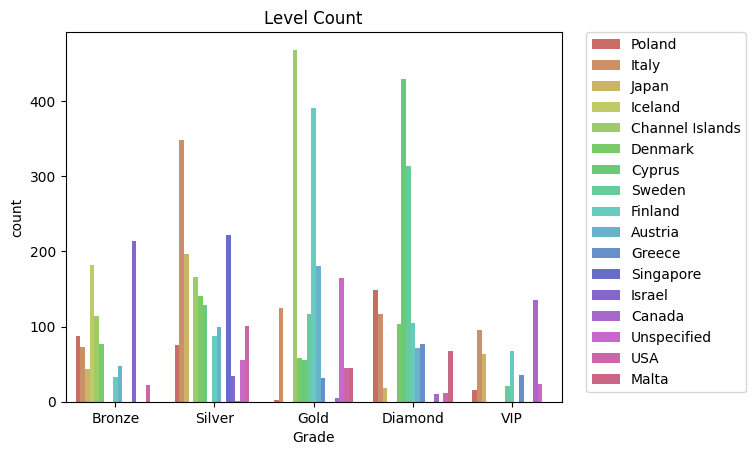

In [264]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP']

sns.countplot(x = 'Grade', data=ci_result_df_100, palette='hls', order=order, hue='Country')
plt.title('Level Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()

In [265]:
ci_result_df_10 = ci_result_df[ci_result_df.Country.isin(ci_country_df[ci_country_df['count'] < 100].Country)]
ci_result_df_10

,CustomerID,Country,Recency,Frequency,Monetary,TotalScore,Grade
5600,15332.0,Lithuania,0.018767,0.004333,0.005943,0.780544,Silver
5601,15332.0,Lithuania,0.018767,0.004333,0.005943,0.780544,Silver
5602,15332.0,Lithuania,0.018767,0.004333,0.005943,0.780544,Silver
5603,15332.0,Lithuania,0.018767,0.004333,0.005943,0.780544,Silver
5604,15332.0,Lithuania,0.018767,0.004333,0.005943,0.780544,Silver
...,...,...,...,...,...,...,...
286397,12446.0,RSA,0.847185,0.007265,0.003586,0.941857,Gold
286398,12446.0,RSA,0.847185,0.007265,0.003586,0.941857,Gold
286399,12446.0,RSA,0.847185,0.007265,0.003586,0.941857,Gold
286400,12446.0,RSA,0.847185,0.007265,0.003586,0.941857,Gold


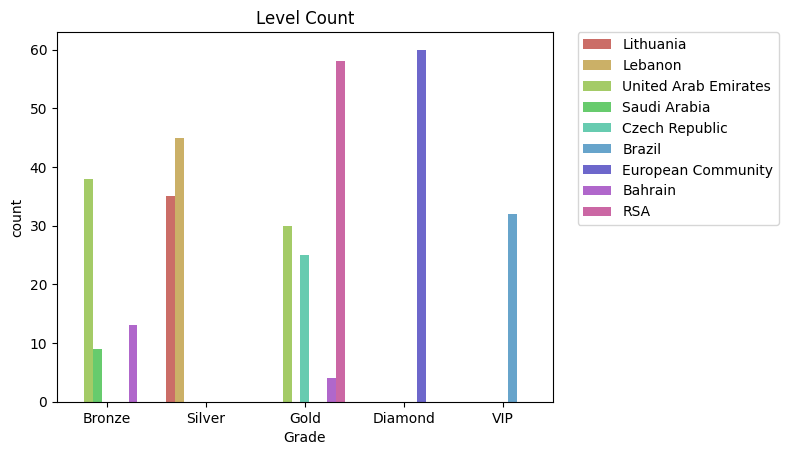

In [266]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Bronze', 'Silver', 'Gold', 'Diamond', 'VIP']

sns.countplot(x = 'Grade', data=ci_result_df_10, palette='hls', order=order, hue='Country')
plt.title('Level Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.show()